# Preprocessing Data Review Goodreads

Dataset ini digunakan untuk mempersiapkan data teks sebelum masuk ke tahap pemodelan Machine Learning dan Deep Learning.

**Input:**  
review_id_mentah.csv  

File ini berisi data mentah hasil scraping atau pengumpulan review, yang umumnya terdiri dari:
- review_id: identitas unik setiap review
- review_text: isi teks review asli (belum dibersihkan)
- spoiler_label: label awal yang menunjukkan apakah review mengandung spoiler (1) atau tidak (0)


**Output:**  
review_preprocessed.csv  

File ini merupakan hasil akhir setelah melalui seluruh tahap preprocessing, seperti pembersihan teks, filtering bahasa, dan pengolahan lanjutan.

Kolom yang dihasilkan:

- **review_text_clean**  
  Teks yang sudah dibersihkan dari noise dan tetap dalam bentuk natural. Digunakan untuk model LSTM.

- **review_text_stem**  
  Teks yang telah diproses dengan stopword removal dan stemming. Digunakan untuk model SVM, Random Forest, dan XGBoost.

- **spoiler_label**  
  Label biner: 1 untuk spoiler, 0 untuk non-spoiler.


Tahapan preprocessing mencakup:
1. Setup Environtmment
2. Load & Inspeksi Awal
3. Deduplikasi (penghapusan data duplikat)
4. filtering bahasa Indonesia
5. Cleaning & Case Folding
6. Filter Panjang Teks
7. Stopword Removal & Stemming 
8. Simpan CSV
9. Vertifikasi 




## 1. Setup Environtment
### a. Install dependencies

In [1]:
# install library yang dibutuhkan
# - PySastrawi : stemmer bahasa indonesia
# - nltk       : untuk stopword bahasa indonesia
# - langdetect : deteksi bahasa ulang di tahap 3
# - matplotlib : visualisasi distribusi label dan panjang teks
# - wordcloud  : visualisasi kata dominan per label

!pip install PySastrawi nltk langdetect pandas tqdm matplotlib wordcloud

### b. Import & Konfigurasi

In [2]:
import re
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from wordcloud import WordCloud
from collections import Counter
from tqdm.notebook import tqdm
from langdetect import detect, LangDetectException
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# download stopword nltk bahasa indonesia
# nltk punya stopword id yang bisa melengkapi stopword sastrawi
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# konfigurasi path
INPUT_CSV  = "review_id_mentah.csv"
OUTPUT_CSV = "review_preprocessed.csv"

# threshold panjang teks minimum setelah cleaning
# review < 20 karakter dianggap tidak informatif untuk klasifikasi
MIN_CHAR_LENGTH = 20

# inisialisasi stemmer & stopword remover sastrawi 
# sastrawi adalah library stemming bahasa indonesia yang paling mature
# dibuat khusus untuk morfologi bahasa indonesia (imbuhan, awalan, akhiran)
stemmer_factory    = StemmerFactory()
stemmer            = stemmer_factory.create_stemmer()

stopword_factory   = StopWordRemoverFactory()
sastrawi_stopwords = set(stopword_factory.get_stop_words())

# gabungkan stopword sastrawi + nltk bahasa indonesia
# supaya coverage lebih luas — sastrawi dan nltk kadang punya kata berbeda
nltk_stopwords_id  = set(stopwords.words("indonesian"))
# gabungkan stopword sastrawi + nltk bahasa indonesia
all_stopwords = sastrawi_stopwords | nltk_stopwords_id

# whitelist — kata-kata ini tidak boleh dihapus meski ada di stopword list
# karena merupakan sinyal penting untuk deteksi spoiler
WHITELIST     = {"ternyata", "akhirnya", "tiba", "tiba-tiba"}
all_stopwords = all_stopwords - WHITELIST 

print(f"total stopword gabungan: {len(all_stopwords)}")

total stopword gabungan: 811


## 2. Load & Inspeksi Awal

Pada tahap ini dilakukan pemuatan data mentah sekaligus inspeksi awal untuk memahami kondisi dataset, meliputi jumlah baris, keberadaan nilai kosong, serta struktur kolom yang tersedia.
Selain itu, distribusi label (spoiler vs non-spoiler) juga diamati sejak awal untuk melihat apakah terdapat ketidakseimbangan kelas yang signifikan. Informasi ini penting sebagai dasar pertimbangan pada tahap pemodelan, terutama pada penanganan data imbalance seperti class weighting atau resampling.

In [3]:
# load data mentah hasil scraping
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print("INSPEKSI AWAL")
print(f"\njumlah baris   : {len(df)}")
print(f"jumlah kolom   : {len(df.columns)}")
print(f"kolom          : {list(df.columns)}")

print("\nmissing values per kolom")
print(df.isnull().sum())

print("\ndistribusi label (sebelum preprocessing)")
label_counts = df["spoiler_label"].value_counts()
label_pct    = df["spoiler_label"].value_counts(normalize=True) * 100
print(pd.DataFrame({
    "jumlah" : label_counts,
    "persen" : label_pct.round(1)
}).rename(index={0: "non-spoiler", 1: "spoiler"}))

print("\n3 sampel data")
df[["review_text", "spoiler_label"]].sample(3, random_state=42)

INSPEKSI AWAL

jumlah baris   : 8757
jumlah kolom   : 8
kolom          : ['book_url', 'review_id', 'reviewer', 'reviewer_url', 'rating', 'created_at', 'review_text', 'spoiler_label']

missing values per kolom
book_url         0
review_id        0
reviewer         6
reviewer_url     0
rating           0
created_at       0
review_text      0
spoiler_label    0
dtype: int64

distribusi label (sebelum preprocessing)
               jumlah  persen
spoiler_label                
non-spoiler      8001    91.4
spoiler           756     8.6

3 sampel data


,review_text,spoiler_label
6054,Meskipun buku ini memiliki 400an lebih halaman...,0
5556,"Padahal udah kena spoiler yang tentang Makoto,...",0
8331,aku baru sadar ternyata ini series terakhir wo...,0


## 3. Deduplikasi

Pada tahap ini dilakukan proses penghapusan data duplikat untuk memastikan setiap entri review bersifat unik dan tidak terjadi bias akibat pengulangan data. Duplikasi dapat terjadi karena beberapa kondisi, seperti reviewer yang sama memberikan ulasan pada entri berbeda dengan teks identik, atau adanya kesalahan pada proses scraping yang menyebabkan pengambilan data berulang.

Proses deduplikasi dilakukan dalam dua pendekatan, yaitu:
1. Berdasarkan review_id sebagai identifier unik dari API Goodreads untuk menghilangkan duplikasi pada level entri.
2. Berdasarkan kesamaan teks ulasan untuk menangani kasus copy-paste atau duplikasi lintas entri buku yang berbeda.


In [4]:
jumlah_awal = len(df)

# hapus duplikat berdasarkan review_id
# review_id itu identifier unik dari api goodreads
df = df.drop_duplicates(subset=["review_id"], keep="first")
print(f"setelah dedup review_id     : {len(df)} baris (hapus {jumlah_awal - len(df)})")

# hapus juga duplikat berdasarkan teks persis sama
# kasus: reviewer copy-paste review yang sama ke beberapa buku
sebelum_text_dedup = len(df)
df = df.drop_duplicates(subset=["review_text"], keep="first")
print(f"setelah dedup teks identik  : {len(df)} baris (hapus {sebelum_text_dedup - len(df)})")

print(f"\ntotal terhapus : {jumlah_awal - len(df)} baris")
print(f"sisa data      : {len(df)} baris")

setelah dedup review_id     : 8757 baris (hapus 0)
setelah dedup teks identik  : 8739 baris (hapus 18)

total terhapus : 18 baris
sisa data      : 8739 baris


## 4. Filter Bahasa Indonesia

Meskipun data telah difilter pada tahap scraping menggunakan langdetect, dilakukan deteksi ulang untuk memastikan konsistensi bahasa pada dataset. Hal ini disebabkan oleh beberapa faktor berikut:
- langdetect bersifat probabilistik sehingga hasil deteksi dapat berbeda antar eksekusi karena adanya komponen acak
- beberapa review dengan teks pendek masih berpotensi salah klasifikasi dan lolos sebagai bahasa lain
- seluruh review diwajibkan menggunakan bahasa Indonesia sesuai ketentuan analisis

Pada tahap ini:
- hanya review yang terdeteksi dominan berbahasa Indonesia yang dipertahankan
- review dengan code-switching (Indonesia–Inggris) tetap dipertahankan karena merupakan fenomena - umum dalam ulasan pengguna Indonesia dan masih informatif untuk klasifikasi spoiler
- review yang terdeteksi dominan berbahasa selain Indonesia dihapus dari dataset


In [ ]:
# cek apakah teks terdeteksi sebagai bahasa Indonesia.
def is_indonesian(text, min_chars=30):
    """
    return true jika teks terdeteksi bahasa indonesia.
    teks < min_chars karakter tidak bisa diandalkan deteksinya,
    jadi langsung return false supaya nanti tersaring di tahap filter panjang.
    """
    # jika teks kosong atau terlalu pendek, langsung dianggap bukan bahasa Indonesia
    if not text or len(str(text).strip()) < min_chars:
        return False
    try:
        # pakai langdetect untuk mendeteksi bahasa
        return detect(str(text)) == "id"
    except LangDetectException:
        return False


# deteksi ulang bahasa untuk setiap review
# tqdm dipakai karena proses ini lambat buat data besar
tqdm.pandas(desc="deteksi bahasa")

sebelum_filter = len(df)
# lakukan deteksi bahasa pada setiap review
df["is_id"] = df["review_text"].progress_apply(is_indonesian)

print(f"terdeteksi bahasa indonesia : {df['is_id'].sum()}")
print(f"terdeteksi bukan indonesia  : {(~df['is_id']).sum()}")

# tampilkan sampel yang akan dibuang untuk verifikasi manual
# pastikan yang dibuang memang bukan bahasa indonesia
print("\n--- sampel review yang akan dibuang ---")
df[~df["is_id"]][["review_text", "spoiler_label"]].head(5)

deteksi bahasa:   0%|          | 0/8739 [00:00<?, ?it/s]

terdeteksi bahasa indonesia : 8710
terdeteksi bukan indonesia  : 29

sampel review yang akan dibuang


,review_text,spoiler_label
187,personally im not really into slow-paced books...,0
229,novel keigo higashino pertama yg kubaca,0
1032,meh. buat yang ga kebiasa baca buku first time...,0
1411,"FAV BANGETTSS!! ceritanya dapet banget,,,apala...",0
1500,"harusnya 200 pages terlalu sedikit nggak, sih?...",0


In [6]:
# buang review yang bukan bahasa indonesia setelah verifikasi sampel di atas
df = df[df["is_id"]].drop(columns=["is_id"]).reset_index(drop=True)

print(f"sebelum filter bahasa : {sebelum_filter} baris")
print(f"setelah filter bahasa : {len(df)} baris")
print(f"terhapus              : {sebelum_filter - len(df)} baris")

sebelum filter bahasa : 8739 baris
setelah filter bahasa : 8710 baris
terhapus              : 29 baris


## 5. Cleaning & Case Folding

Tahap ini bertujuan untuk membersihkan teks dari berbagai noise serta menyeragamkan bentuk teks sebelum digunakan sebagai input model LSTM.

Proses yang dilakukan meliputi:
-  penghapusan URL, mention, hashtag, tag HTML, serta karakter non-alfanumerik yang tidak relevan.
-  normalisasi spasi dan case folding (konversi ke huruf kecil).

Pada tahap ini, angka dan tanda baca sederhana tetap dipertahankan karena dapat mengandung informasi yang relevan untuk analisis spoiler dan membantu pemahaman struktur kalimat oleh model.

In [7]:
def clean_text(text):
    """
    membersihkan teks review dari noise tanpa menghilangkan makna.
    hasil fungsi ini dipakai langsung oleh lstm sebagai review_text_clean.
    """
    if not text or pd.isna(text):
        return ""

    text = str(text)

    # hapus url (http/https/www)
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # hapus mention dan hashtag
    text = re.sub(r"@\w+|#\w+", " ", text)

    # hapus tag html yang mungkin masih tersisa dari scraping
    text = re.sub(r"<[^>]+>", " ", text)

    # hapus karakter non-alfanumerik kecuali spasi dan tanda baca dasar
    # pertahankan: huruf, angka, spasi, titik, koma, tanda tanya, tanda seru
    text = re.sub(r"[^\w\s.,!?]", " ", text)

    # normalisasi spasi — hapus spasi ganda, tab, newline
    text = re.sub(r"\s+", " ", text).strip()

    # case folding — semua huruf jadi lowercase
    # supaya 'Mati' dan 'mati' dianggap token yang sama oleh model
    text = text.lower()

    return text


# terapkan cleaning ke seluruh dataset
tqdm.pandas(desc="cleaning teks")
df["review_text_clean"] = df["review_text"].progress_apply(clean_text)

# verifikasi hasil cleaning — bandingkan teks asli vs bersih
print("contoh hasil cleaning")
for i in df.sample(3, random_state=42).index:
    print(f"\n[asli]  : {df.loc[i, 'review_text'][:200]}")
    print(f"[clean] : {df.loc[i, 'review_text_clean'][:200]}")
    print("-" * 60)

cleaning teks:   0%|          | 0/8710 [00:00<?, ?it/s]

contoh hasil cleaning

[asli]  : Awalnya seruu, tapi ditengah-tengah cerita kaya.... hmmm okeyy.. asumsi dan teorinya kurihara sama uketsu terlalu berlebihan, tapi aku suka sama imajinasi liarnya yang ternyata ada beberapa yg jadi ke
[clean] : awalnya seruu, tapi ditengah tengah cerita kaya.... hmmm okeyy.. asumsi dan teorinya kurihara sama uketsu terlalu berlebihan, tapi aku suka sama imajinasi liarnya yang ternyata ada beberapa yg jadi ke
------------------------------------------------------------

[asli]  : Comeback baca buku lagi tahun ini. Kelarin 1 hari. Gak tau ceritanya yang seru mudah dipahami atau kemampuan baca masih bagus. Kayaknya sih alasan pertama ya. Baca novel ini bikin kita belajar buat ga
[clean] : comeback baca buku lagi tahun ini. kelarin 1 hari. gak tau ceritanya yang seru mudah dipahami atau kemampuan baca masih bagus. kayaknya sih alasan pertama ya. baca novel ini bikin kita belajar buat ga
------------------------------------------------------------

[asli]  :

## 6. Filter Panjang Teks

Tahap ini bertujuan untuk menghapus review yang terlalu pendek setelah proses cleaning, karena tidak mengandung cukup informasi untuk proses klasifikasi. Review dengan panjang di bawah threshold tertentu dianggap tidak informatif dan berpotensi mengganggu performa model dalam memahami konteks teks.Pada tahap ini digunakan batas minimum panjang teks, yaitu kurang dari 20 karakter setelah proses cleaning, sehingga review dengan panjang di bawah batas tersebut dihapus dari dataset.

In [8]:
sebelum_filter_panjang = len(df)

# hitung panjang teks setelah cleaning
df["text_len"] = df["review_text_clean"].str.len()

# tampilkan distribusi panjang sebelum filter
print("distribusi panjang teks (karakter)")
print(df["text_len"].describe().round(1))

# tampilkan review yang akan dibuang untuk verifikasi
akan_dibuang = df[df["text_len"] < MIN_CHAR_LENGTH]
print(f"\nreview < {MIN_CHAR_LENGTH} karakter yang akan dibuang: {len(akan_dibuang)}")
if len(akan_dibuang) > 0:
    print(akan_dibuang[["review_text_clean", "spoiler_label"]].head(10))

# filter
df = df[df["text_len"] >= MIN_CHAR_LENGTH].reset_index(drop=True)

print(f"\nsebelum filter panjang : {sebelum_filter_panjang} baris")
print(f"setelah filter panjang : {len(df)} baris")
print(f"terhapus               : {sebelum_filter_panjang - len(df)} baris")

distribusi panjang teks (karakter)
count     8710.0
mean       740.4
std        860.9
min         13.0
25%        191.0
50%        445.0
75%        973.8
max      11849.0
Name: text_len, dtype: float64

review < 20 karakter yang akan dibuang: 3
       review_text_clean  spoiler_label
4999  buku ini membuatku              0
7747       review ada di              0
8147   review lengkap di              0

sebelum filter panjang : 8710 baris
setelah filter panjang : 8707 baris
terhapus               : 3 baris


## 7. Stopword Removal & Stemming 

Tahap ini untuk menyederhanakan teks dengan menghapus kata umum (stopword) dan mengubah kata ke bentuk dasarnya (stemming). Hasil dari tahap ini digunakan sebagai input untuk model SVM, Random Forest, dan XGBoost. Selanjutnya, dilakukan stemming menggunakan PySastrawi untuk normalisasi. Tahap ini tidak diterapkan pada model LSTM, karena model berbasis deep learning lebih bergantung pada urutan dan bentuk asli kata untuk menangkap konteks kalimat.

In [9]:
def remove_stopwords(text, stopwords_set):
    # hapus stopword dari teks dengan tokenisasi sederhana berbasis spasi
     # jika teks kosong, kembalikan string kosong
    if not text:
        return ""
    tokens = text.split()
    tokens_filtered = [t for t in tokens if t not in stopwords_set]
    return " ".join(tokens_filtered)

# stemming menggunakan sastrawi
def stem_text(text, stemmer):
    if not text:
        return ""
    return stemmer.stem(text)

# stopword removal dari review_text_clean
tqdm.pandas(desc="stopword removal")
df["review_text_nostop"] = df["review_text_clean"].progress_apply(
    lambda x: remove_stopwords(x, all_stopwords)
)

# stemming dari hasil stopword removal
tqdm.pandas(desc="stemming")
df["review_text_stem"] = df["review_text_nostop"].progress_apply(
    lambda x: stem_text(x, stemmer)
)

# hapus kolom sementara yang tidak diperlukan di output akhir
df = df.drop(columns=["review_text_nostop"])

# verifikasi hasil (bandingkan clean vs stem)
print("contoh hasil stopword removal + stemming")
for i in df.sample(3, random_state=42).index:
    print(f"\n[clean] : {df.loc[i, 'review_text_clean'][:200]}")
    print(f"[stem]  : {df.loc[i, 'review_text_stem'][:200]}")
    print("-" * 60)

stopword removal:   0%|          | 0/8707 [00:00<?, ?it/s]

stemming:   0%|          | 0/8707 [00:00<?, ?it/s]

contoh hasil stopword removal + stemming

[clean] : awalnya seruu, tapi ditengah tengah cerita kaya.... hmmm okeyy.. asumsi dan teorinya kurihara sama uketsu terlalu berlebihan, tapi aku suka sama imajinasi liarnya yang ternyata ada beberapa yg jadi ke
[stem]  : seruu tengah cerita kaya hmmm okeyy asumsi teori kurihara uketsu lebih suka imajinasi liar nyata yg kenyataann buku gak bikin penasaran banget baca 3 stars from me
------------------------------------------------------------

[clean] : comeback baca buku lagi tahun ini. kelarin 1 hari. gak tau ceritanya yang seru mudah dipahami atau kemampuan baca masih bagus. kayaknya sih alasan pertama ya. baca novel ini bikin kita belajar buat ga
[stem]  : comeback baca buku ini kelarin 1 hari gak tau cerita seru mudah paham mampu baca bagus kayak sih alas ya baca novel bikin ajar ga percaya gitu aja deskripsi tokoh lembar nebak laku nebak motif gak neb
------------------------------------------------------------

[clean] : sebuah kisah bala

## 8. Simpan CSV

In [10]:
# simpan hanya kolom yang diperlukan untuk modeling
# kolom lain (book_url, reviewer, rating, dll) tidak dibutuhkan di tahap modeling
df_output = df[["review_text_clean", "review_text_stem", "spoiler_label"]].copy()

df_output.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"tersimpan : {OUTPUT_CSV}")
print(f"total baris : {len(df_output)}")
print(f"kolom       : {list(df_output.columns)}")
print("\n3 sampel output")
df_output.sample(3, random_state=42)

tersimpan : review_preprocessed.csv
total baris : 8707
kolom       : ['review_text_clean', 'review_text_stem', 'spoiler_label']

3 sampel output


,review_text_clean,review_text_stem,spoiler_label
1226,"awalnya seruu, tapi ditengah tengah cerita kay...",seruu tengah cerita kaya hmmm okeyy asumsi teo...,1
2893,comeback baca buku lagi tahun ini. kelarin 1 h...,comeback baca buku ini kelarin 1 hari gak tau ...,0
6595,sebuah kisah balas dendam yg sangatlah epik se...,kisah balas dendam yg epik guru yg percaya mat...,0


## 9. Vertifikasi

Pada tahap ini, hasil preprocessing disimpan dalam bentuk file CSV dan dilakukan verifikasi sebelum digunakan pada tahap modeling.

Verifikasi dilakukan untuk memastikan kualitas data, meliputi:
- jumlah data yang memadai untuk pelatihan model
- distribusi label yang tidak terlalu timpang
- hasil cleaning dan stemming tetap mempertahankan makna teks
- tidak terdapat data kosong atau anomali yang dapat memengaruhi proses training

Proses verifikasi dilakukan secara bertahap (V1–V10) untuk memastikan seluruh aspek data telah sesuai.Apabila ditemukan ketidaksesuaian pada tahap ini, maka perlu dilakukan perbaikan pada tahap preprocessing sebelum melanjutkan ke proses modeling.

## V1. Ringkasan Perubahan Data per Tahap

Bagian ini menampilkan ringkasan jumlah data pada setiap tahap preprocessing untuk melihat perubahan ukuran dataset secara keseluruhan. Hal ini bertujuan untuk mengidentifikasi apakah terdapat tahap yang mengurangi data secara signifikan serta memastikan jumlah data akhir tetap memadai untuk proses modeling. Jika ditemukan pengurangan data yang terlalu besar pada tahap tertentu atau jumlah data akhir terlalu sedikit, maka perlu dilakukan evaluasi kembali pada proses preprocessing atau pengumpulan data.

In [21]:
# rekap jumlah data di setiap tahap
# variabel jumlah_awal, sebelum_filter, sebelum_filter_panjang sudah didefinisikan di sel sebelumnya

print("RINGKASAN PERUBAHAN DATA PER TAHAP")

stages = [
    ("data mentah (scraping)",        jumlah_awal),
    ("setelah deduplikasi",            sebelum_filter),
    ("setelah filter bahasa",          sebelum_filter_panjang),
    ("setelah filter panjang (final)", len(df_output)),
]

prev = None
for nama, jumlah in stages:
    if prev is not None:
        selisih = prev - jumlah
        pct     = selisih / prev * 100
        print(f"{nama:<40} : {jumlah:>5} baris  (↓ {selisih} / -{pct:.1f}%)")
    else:
        print(f"{nama:<40} : {jumlah:>5} baris")
    prev = jumlah

print("-" * 70)
total_hilang = jumlah_awal - len(df_output)
print(f"{'total data hilang':<40} : {total_hilang:>5} baris  ({total_hilang/jumlah_awal*100:.1f}%)")
print(f"{'data final':<40} : {len(df_output):>5} baris  ({len(df_output)/jumlah_awal*100:.1f}%)")

RINGKASAN PERUBAHAN DATA PER TAHAP
data mentah (scraping)                   :  8757 baris
setelah deduplikasi                      :  8739 baris  (↓ 18 / -0.2%)
setelah filter bahasa                    :  8710 baris  (↓ 29 / -0.3%)
setelah filter panjang (final)           :  8707 baris  (↓ 3 / -0.0%)
----------------------------------------------------------------------
total data hilang                        :    50 baris  (0.6%)
data final                               :  8707 baris  (99.4%)


## V2. Distribusi Label (Sebelum vs Sesudah Preprocessing)

Bagian ini menampilkan perbandingan distribusi label spoiler dan non-spoiler sebelum dan sesudah preprocessing. Tujuannya adalah untuk melihat apakah terjadi perubahan proporsi label yang signifikan serta mengidentifikasi potensi ketidakseimbangan kelas pada dataset. Distribusi label yang terlalu timpang dapat memengaruhi performa model, sehingga perlu menjadi pertimbangan pada tahap modeling, misalnya dengan penggunaan teknik penanganan imbalance seperti penyesuaian bobot kelas atau resampling.

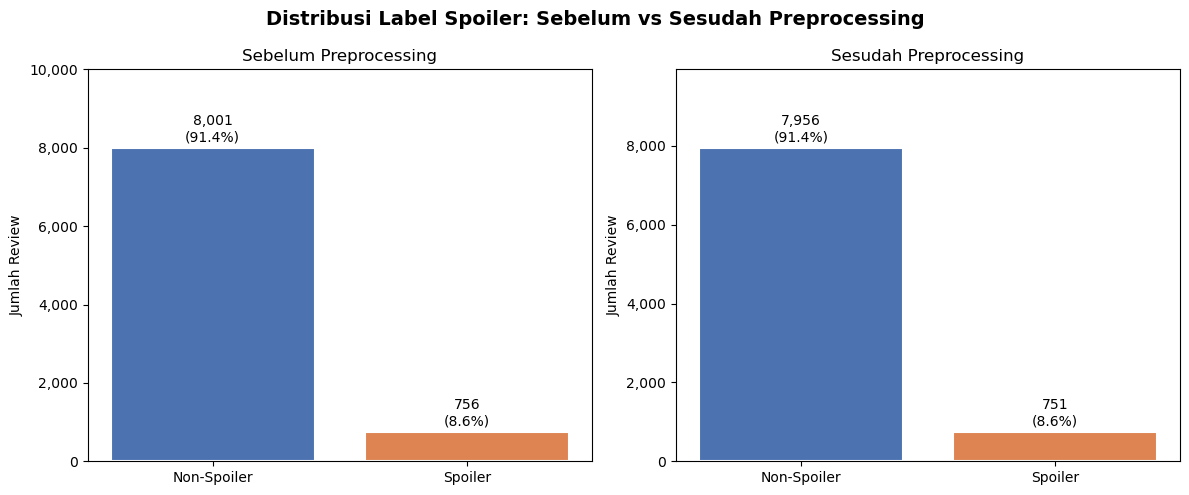

rasio mayoritas:minoritas = 10.59:1
imbalanced


In [22]:
# buat 2 subplot: sebelum vs sesudah preprocessing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribusi Label Spoiler: Sebelum vs Sesudah Preprocessing", fontsize=14, fontweight="bold")

# load ulang data mentah untuk perbandingan
df_raw      = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
label_before = df_raw["spoiler_label"].value_counts().rename({0: "Non-Spoiler", 1: "Spoiler"})
label_after  = df_output["spoiler_label"].value_counts().rename({0: "Non-Spoiler", 1: "Spoiler"})

colors = ["#4C72B0", "#DD8452"]

# loop untuk plot sebelum dan sesudah
for ax, data, title in zip(
    axes,
    [label_before, label_after],
    ["Sebelum Preprocessing", "Sesudah Preprocessing"]
):
    bars = ax.bar(data.index, data.values, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Jumlah Review")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # label angka dan persentase di atas setiap bar
    total = data.sum()
    for bar, val in zip(bars, data.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.01,
            f"{val:,}\n({val/total*100:.1f}%)",
            ha="center", va="bottom", fontsize=10
        )
    ax.set_ylim(0, data.max() * 1.25)

plt.tight_layout()
plt.savefig("v2_distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

# hitung rasio imbalance
counts_final = df_output["spoiler_label"].value_counts()
rasio = counts_final.max() / counts_final.min()
print(f"rasio mayoritas:minoritas = {rasio:.2f}:1")
if rasio <= 2:
    print("distribusi seimbang")
elif rasio <= 4:
    print("sedikit timpang")
else:
    print("imbalanced")

## V3. Distribusi Panjang Teks

Bagian ini menampilkan distribusi panjang teks dari review_text_clean dan review_text_stem untuk memahami sebaran karakter pada dataset.Informasi ini digunakan sebagai dasar dalam menentukan parameter pada tahap modeling, khususnya untuk model LSTM dalam penentuan nilai maxlen, agar panjang input dapat diatur secara optimal tanpa banyak kehilangan informasi.Selain itu, distribusi ini juga membantu mengidentifikasi adanya teks yang terlalu pendek atau terlalu panjang yang berpotensi menjadi outlier.


review_text_clean
  min    : 22
  median : 446
  mean   : 741
  p90    : 1772  <- kandidat maxlen untuk LSTM
  p95    : 2320
  max    : 11849

review_text_stem
  min    : 4
  median : 246
  mean   : 393
  p90    : 917  <- kandidat maxlen untuk LSTM
  p95    : 1199
  max    : 6470


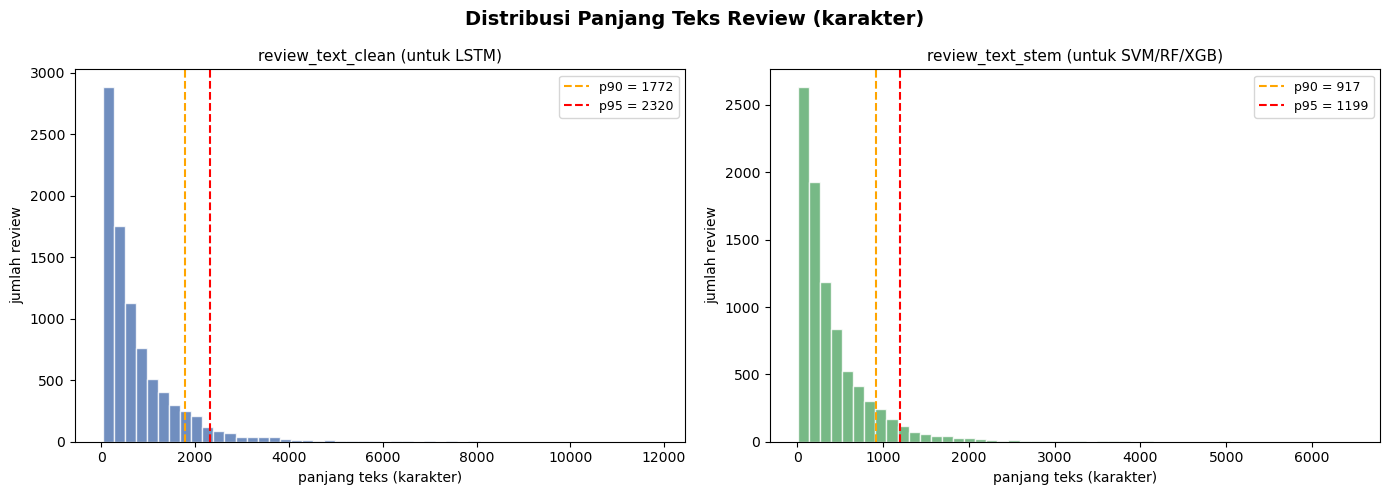

In [13]:
# buat 2 subplot untuk membandingkan distribusi panjang teks
# antara review_text_clean (LSTM) dan review_text_stem (ML klasik)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Panjang Teks Review (karakter)", fontsize=14, fontweight="bold")

for ax, col, title, color in zip(
    axes,
    ["review_text_clean", "review_text_stem"],
    ["review_text_clean (untuk LSTM)", "review_text_stem (untuk SVM/RF/XGB)"],
    ["#4C72B0", "#55A868"]
):
    lengths = df_output[col].str.len()
    p90 = lengths.quantile(0.90)
    p95 = lengths.quantile(0.95)

    ax.hist(lengths, bins=50, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(p90, color="orange", linestyle="--", linewidth=1.5, label=f"p90 = {p90:.0f}")
    ax.axvline(p95, color="red",    linestyle="--", linewidth=1.5, label=f"p95 = {p95:.0f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("panjang teks (karakter)")
    ax.set_ylabel("jumlah review")
    ax.legend(fontsize=9)

    print(f"\n{col}")
    print(f"  min    : {lengths.min():.0f}")
    print(f"  median : {lengths.median():.0f}")
    print(f"  mean   : {lengths.mean():.0f}")
    print(f"  p90    : {p90:.0f}  <- kandidat maxlen untuk LSTM")
    print(f"  p95    : {p95:.0f}")
    print(f"  max    : {lengths.max():.0f}")

plt.tight_layout()
plt.savefig("v3_distribusi_panjang_teks.png", dpi=150, bbox_inches="tight")
plt.show()

## V4. Verifikasi Kualitas Teks (Sampel per Label)

Melakukan pengecekan secara manual terhadap beberapa sampel teks dari masing-masing label. Verifikasi dilakukan untuk memastikan kesesuaian antara isi review dan label yang diberikan, serta memastikan bahwa hasil preprocessing tidak merusak makna teks.Selain itu, tahap ini juga membantu mengidentifikasi potensi ketidaksesuaian label dari sumber data. Jika ditemukan banyak label yang kurang sesuai, hal tersebut perlu dicatat sebagai keterbatasan dataset.

In [14]:
# tampilkan 5 sampel per label
# bandingkan review_text_clean vs review_text_stem untuk setiap sampel

for label, nama_label in [(1, "SPOILER"), (0, "NON-SPOILER")]:
    print(f"SAMPEL LABEL {label} — {nama_label}")
    print("-" * 65)

    subset = df_output[df_output["spoiler_label"] == label].sample(
        min(5, len(df_output[df_output["spoiler_label"] == label])),
        random_state=42
    )

    for idx, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"\n[{idx}] clean : {row['review_text_clean'][:300]}")
        print(f"    stem  : {row['review_text_stem'][:300]}")
        print("-" * 65)

SAMPEL LABEL 1 — SPOILER
-----------------------------------------------------------------

[1] clean : jadi, sebetulnya buku ini sudah saya miliki sejak awal rilis. namun, baru sempat terbaca ditambah kabarnya buku ini ada tulisan yang paling populer dari tulisan lain akiyoshi rikako sehingga saya mencari waktu yang tepat agar tidak terganggu sedikitpun ketika membacanya. hehe . tidak heran, mengapa 
    stem  : jadi buku milik rilis namun baca tambah kabar buku tulis populer tulis akiyoshi rikako cari ganggu sedikit baca hehe heran holy mother rating reviews kalah baik buku saji misteri sendiri buku kisah juang lindung anak jenis bahaya gemas honami bersikukuh hideki laku tengah cerita ungkap gamblang laku
-----------------------------------------------------------------

[2] clean : seru si dikasih tau tau psikologi tu membantu banyak hal, tapi gua mumet sama perkodingannya kalau alurnya oke oke aja si. mau baca yg lebih banyak terkait itu
    stem  : seru si kasih tau tau psikologi

## V5. Verifikasi Kualitas Stemming

Menampilkan kata-kata yang paling sering muncul beserta hasil stemming untuk melihat konsistensi perubahan kata ke bentuk dasarnya. Hal yang diperhatikan meliputi kewajaran hasil stemming, kemungkinan perubahan kata menjadi tidak bermakna, serta konsistensi penggabungan variasi kata yang seharusnya memiliki akar yang sama. Perlu diperhatikan bahwa Sastrawi memiliki keterbatasan, terutama pada kata informal, slang, atau nama khusus, sehingga hasil yang kurang sempurna masih dapat terjadi.

In [15]:
# kumpulin semua kata dari review_text_clean
# filter stopword supaya hasil lebih informatif
# lalu bandingkan dengan hasil stemnya

all_words_clean = " ".join(df_output["review_text_clean"].dropna()).split()
word_freq = Counter(all_words_clean)

# ambil 50 kata paling sering yang bukan stopword dan panjang > 3 karakter
top_words = [
    (word, freq)
    for word, freq in word_freq.most_common(200)
    if word not in all_stopwords and len(word) > 3
][:50]

# bandingkan kata asli vs hasil stemming
stem_comparison = []
for word, freq in top_words:
    stemmed = stemmer.stem(word)
    berubah = "ya" if word != stemmed else "-"
    stem_comparison.append({
        "kata asli" : word,
        "hasil stem": stemmed,
        "berubah?"  : berubah,
        "frekuensi" : freq
    })

df_stem_check = pd.DataFrame(stem_comparison)
print("50 kata paling sering (non-stopword) dan hasil stemming-nya:\n")
print(df_stem_check.to_string(index=False))

n_berubah = (df_stem_check["berubah?"] == "ya").sum()
print(f"\ndari {len(df_stem_check)} kata: {n_berubah} berubah setelah stem, {len(df_stem_check)-n_berubah} tetap")

50 kata paling sering (non-stopword) dan hasil stemming-nya:

 kata asli hasil stem berubah?  frekuensi
      buku       buku        -      11098
     novel      novel        -       5869
      baca       baca        -       5142
    cerita     cerita        -       4803
     bikin      bikin        -       3608
      plot       plot        -       3108
    banget     banget        -       2806
      suka       suka        -       2612
      ini.        ini       ya       2608
     tokoh      tokoh        -       2523
     twist      twist        -       2358
   membaca       baca       ya       2293
  ternyata      nyata       ya       2216
      anak       anak        -       2207
     nggak      nggak        -       2145
   pembaca       baca       ya       1987
  detektif   detektif        -       1939
 ceritanya     cerita       ya       1907
pembunuhan      bunuh       ya       1856
      udah       udah        -       1850
   misteri    misteri        -       1839
   penulis    

## V6. Distribusi Panjang Teks per Label

Menampilkan perbandingan panjang teks antara review spoiler dan non-spoiler untuk melihat perbedaan pola distribusi. Perbedaan panjang teks dapat memberikan indikasi awal apakah terdapat karakteristik tertentu pada masing-masing label. Jika distribusi terlihat berbeda, panjang teks berpotensi menjadi fitur tambahan dalam modeling. Sebaliknya, jika distribusi serupa, maka model lebih bergantung pada konten kata dalam membedakan label.

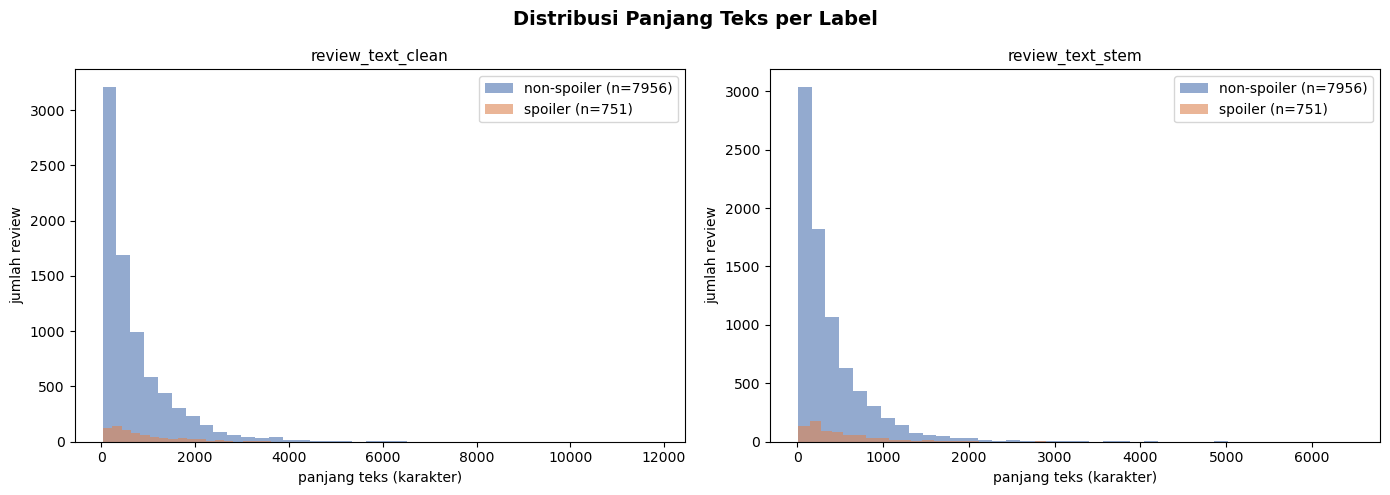


rata-rata panjang teks per label (review_text_clean):
spoiler_label       
non-spoiler    count     7956.0
               mean       722.1
               std        851.5
               min         22.0
               25%        181.0
               50%        429.0
               75%        947.0
               max      11849.0
spoiler        count      751.0
               mean       936.9
               std        933.4
               min         32.0
               25%        324.0
               50%        652.0
               75%       1285.5
               max       7984.0
Name: review_text_clean, dtype: float64


In [16]:
# buat 2 subplot untuk membandingkan panjang teks per label
# antara review_text_clean dan review_text_stem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Panjang Teks per Label", fontsize=14, fontweight="bold")

for ax, col, title in zip(
    axes,
    ["review_text_clean", "review_text_stem"],
    ["review_text_clean", "review_text_stem"]
):
    for label, nama, color in [(0, "non-spoiler", "#4C72B0"), (1, "spoiler", "#DD8452")]:
        lengths = df_output[df_output["spoiler_label"] == label][col].str.len()
        ax.hist(lengths, bins=40, alpha=0.6, label=f"{nama} (n={len(lengths)})", color=color)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("panjang teks (karakter)")
    ax.set_ylabel("jumlah review")
    ax.legend()

plt.tight_layout()
plt.savefig("v6_panjang_teks_per_label.png", dpi=150, bbox_inches="tight")
plt.show()

# statistik panjang per label
print("\nrata-rata panjang teks per label (review_text_clean):")
print(
    df_output.groupby("spoiler_label")["review_text_clean"]
    .apply(lambda x: x.str.len().describe().round(1))
    .rename(index={0: "non-spoiler", 1: "spoiler"})
)

## V7. Wordcloud per Label

Menampilkan kata-kata yang paling sering muncul pada masing-masing label (Wordcloud) untuk melihat perbedaan pola kata antara review spoiler dan non-spoiler. Perbedaan kata yang muncul dapat memberikan indikasi awal terhadap kata-kata yang berpotensi menjadi sinyal penting dalam klasifikasi. Jika kedua wordcloud terlihat serupa, maka diperlukan pendekatan fitur yang lebih kuat pada tahap modeling. Visualisasi dibuat menggunakan review_text_stem agar kata yang ditampilkan lebih representatif dan tidak didominasi oleh stopword.

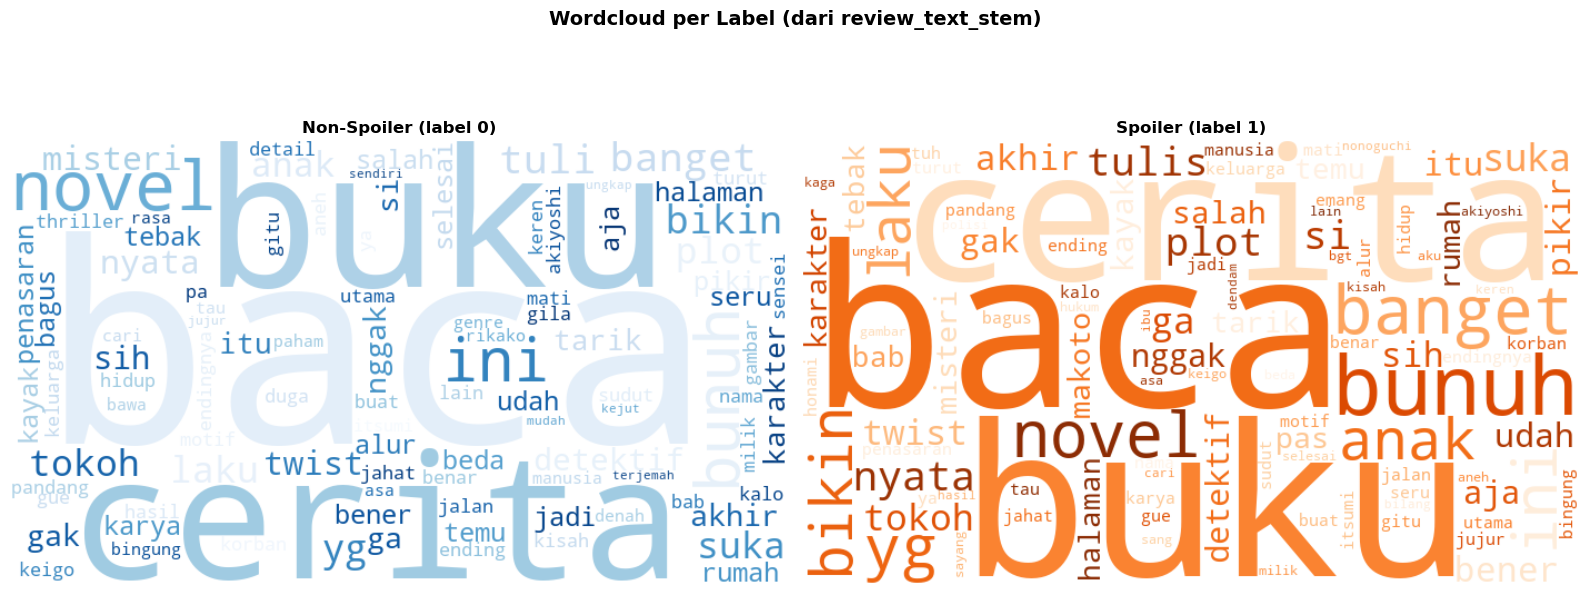

In [17]:
# buat 2 subplot untuk wordcloud per label (non-spoiler vs spoiler)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Wordcloud per Label (dari review_text_stem)", fontsize=14, fontweight="bold")

# loop untuk masing-masing label
for ax, label, nama, colormap in [
    (axes[0], 0, "Non-Spoiler (label 0)", "Blues"),
    (axes[1], 1, "Spoiler (label 1)",     "Oranges")
]:
    corpus = " ".join(
        df_output[df_output["spoiler_label"] == label]["review_text_stem"].dropna()
    )

    if not corpus.strip():
        ax.text(0.5, 0.5, "tidak ada data", ha="center", va="center")
        ax.set_title(nama)
        ax.axis("off")
        continue

    wc = WordCloud(
        width=700, height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
        collocations=False  # hindari pasangan kata yang terlalu sering muncul bersamaan
    ).generate(corpus)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(nama, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("v7_wordcloud_per_label.png", dpi=150, bbox_inches="tight")
plt.show()

## V8. Top 20 Kata per Label

Menampilkan kata-kata yang paling sering muncul pada masing-masing label beserta frekuensinya sebagai representasi numerik dari wordcloud.Perbandingan frekuensi antar label membantu mengidentifikasi kata yang bersifat umum maupun kata yang lebih spesifik pada salah satu label. Kata yang memiliki perbedaan frekuensi mencolok berpotensi menjadi fitur yang lebih informatif dalam proses klasifikasi.

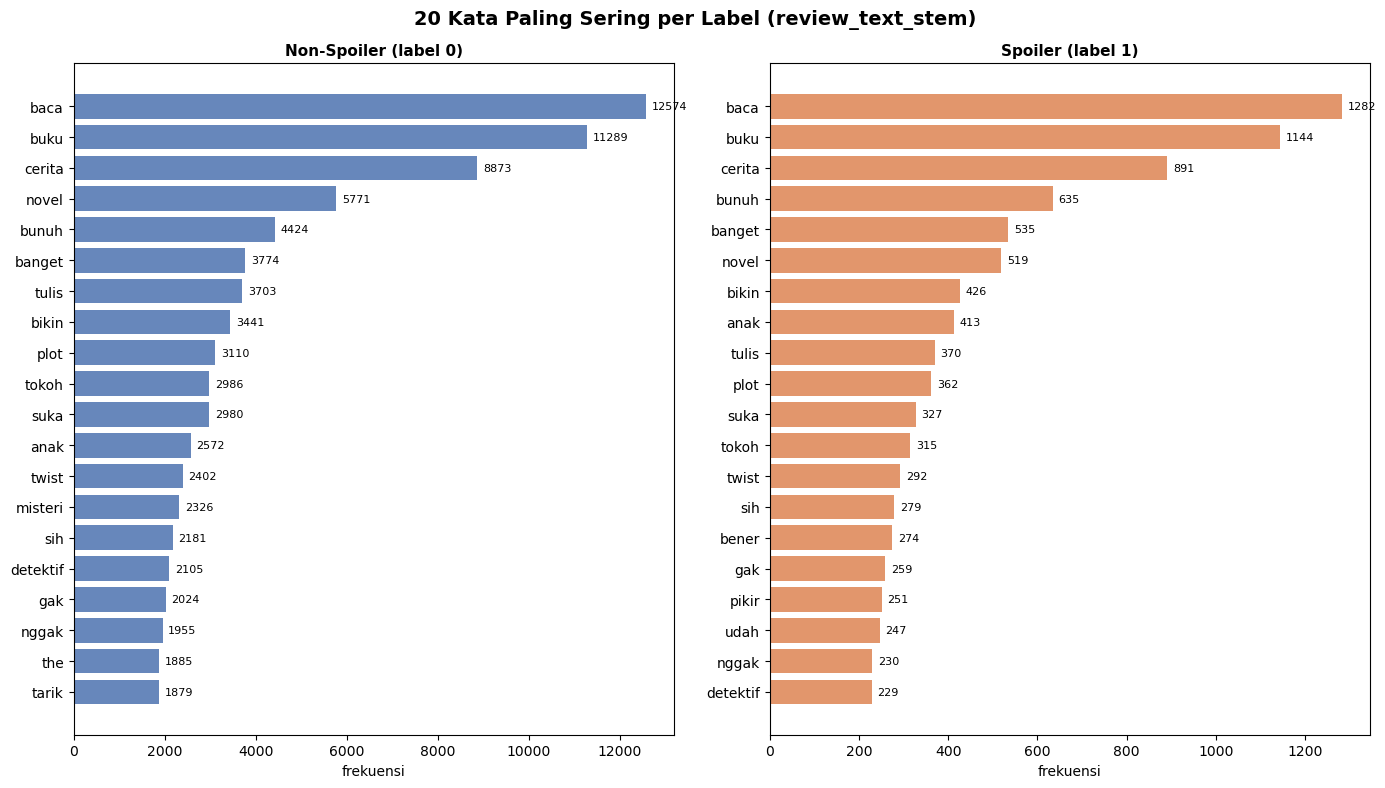

In [18]:

# buat 2 subplot untuk menampilkan top kata per label
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle("20 Kata Paling Sering per Label (review_text_stem)", fontsize=14, fontweight="bold")

for ax, label, nama, color in [
    (axes[0], 0, "Non-Spoiler (label 0)", "#4C72B0"),
    (axes[1], 1, "Spoiler (label 1)",     "#DD8452")
]:
    words = " ".join(
        df_output[df_output["spoiler_label"] == label]["review_text_stem"].dropna()
    ).split()

    # filter stopword dan kata sangat pendek
    words_filtered = [w for w in words if w not in all_stopwords and len(w) > 2]
    top20 = Counter(words_filtered).most_common(20)

    if not top20:
        ax.text(0.5, 0.5, "tidak ada data", ha="center", va="center")
        ax.set_title(nama)
        continue

    kata, freq = zip(*top20)
    bars = ax.barh(list(reversed(kata)), list(reversed(freq)), color=color, alpha=0.85)
    ax.set_title(nama, fontsize=11, fontweight="bold")
    ax.set_xlabel("frekuensi")

    # label angka di ujung setiap bar
    for bar, val in zip(bars, list(reversed(freq))):
        ax.text(
            bar.get_width() + freq[0] * 0.01,
            bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8
        )

plt.tight_layout()
plt.savefig("v8_top_kata_per_label.png", dpi=150, bbox_inches="tight")
plt.show()

## V9. Checklist Verifikasi Otomatis

Merangkum kondisi yang perlu dipastikan sebelum melanjutkan ke tahap modeling.

Hal yang perlu diperhatikan meliputi:
- jumlah data sudah memadai untuk pelatihan model
- distribusi label tidak terlalu timpang
- tidak terdapat baris kosong pada review_text_clean maupun review_text_stem
- tidak terdapat missing value pada dataset
- jumlah kelas label lengkap (dua kelas)

Apabila terdapat kondisi yang belum terpenuhi, maka perlu dilakukan evaluasi dan perbaikan pada tahap preprocessing sebelum melanjutkan ke proses modeling. Setelah seluruh kondisi terpenuhi, data dapat digunakan pada tahap modeling.

In [27]:
# checklist otomatis sebagai validasi akhir sebelum modeling
print("CHECKLIST VERIFIKASI AKHIR")

checks = []

# 1. jumlah data
n  = len(df_output)
ok = n >= 500
checks.append((
    ok,
    f"jumlah data: {n}",
    "aman" if ok else "kurang"
))

# 2. rasio imbalance
counts = df_output["spoiler_label"].value_counts()
rasio  = counts.max() / counts.min()
ok     = rasio <= 4
checks.append((
    ok,
    f"rasio imbalance: {rasio:.2f}:1",
    "aman" if ok else "imbalanced"
))

# 3. baris kosong review_text_clean
n_empty_clean = (df_output["review_text_clean"].str.strip() == "").sum()
ok = n_empty_clean == 0
checks.append((
    ok,
    f"baris kosong review_text_clean: {n_empty_clean}",
    "aman" if ok else "ada baris kosong (cek fungsi clean_text)"
))

# 4. baris kosong review_text_stem
n_empty_stem = (df_output["review_text_stem"].str.strip() == "").sum()
ok = n_empty_stem == 0
checks.append((
    ok,
    f"baris kosong review_text_stem: {n_empty_stem}",
    "aman" if ok else f"ada {n_empty_stem} baris kosong"
))

# 5. missing value
n_null = df_output.isnull().sum().sum()
ok = n_null == 0
checks.append((
    ok,
    f"total missing value: {n_null}",
    "aman" if ok else "ada missing value, cek tahap mana yang menghasilkan nan"
))

# 6. minimal ada kedua label
n_label = df_output["spoiler_label"].nunique()
ok = n_label == 2
checks.append((
    ok,
    f"jumlah kelas label: {n_label}",
    "aman" if ok else "hanya 1 kelas, tidak bisa training klasifikasi biner"
))

# tampilkan hasil
semua_ok = True
for ok, kondisi, keterangan in checks:
    status   = "(OK)" if ok else "(!!)"
    semua_ok = semua_ok and ok
    print(f"{status}  {kondisi}")
    print(f"      {keterangan}")

if semua_ok:
    print("semua ok")
else:
    print("ada cek yang gak ok")

CHECKLIST VERIFIKASI AKHIR
(OK)  jumlah data: 8707
      aman
(!!)  rasio imbalance: 10.59:1
      imbalanced
(OK)  baris kosong review_text_clean: 0
      aman
(OK)  baris kosong review_text_stem: 0
      aman
(OK)  total missing value: 0
      aman
(OK)  jumlah kelas label: 2
      aman
ada cek yang gak ok


## V10. Penanganan Baris Kosong di review_text_stem
Menangani kemungkinan adanya baris kosong yang dihasilkan setelah proses stopword removal, terutama pada teks yang sangat pendek. Baris kosong perlu dihapus karena tidak memberikan informasi bagi model dan dapat memengaruhi proses representasi fitur maupun training. Langkah ini dilakukan hanya jika pada tahap verifikasi sebelumnya ditemukan adanya baris kosong pada review_text_stem. Jika tidak ditemukan, maka tidak diperlukan tindakan tambahan.

In [23]:
# cek dan tangani baris kosong di review_text_stem
kosong_stem = df_output["review_text_stem"].str.strip() == ""

if kosong_stem.sum() == 0:
    print("tidak ada baris kosong di review_text_stem")
else:
    print(f"ditemukan {kosong_stem.sum()} baris kosong di review_text_stem")
    print("\nsampel baris yang kosong (teks clean-nya sebelum stemming):")
    print(df_output[kosong_stem][["review_text_clean", "spoiler_label"]].head(10))

    # buang baris yang review_text_stem-nya kosong
    df_output = df_output[~kosong_stem].reset_index(drop=True)

    # simpan ulang csv yang sudah bersih
    df_output.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

    print(f"\nbaris kosong dibuang — data final: {len(df_output)} review")
    print(f"csv diperbarui: {OUTPUT_CSV}")

tidak ada baris kosong di review_text_stem
